-------------------------------
#                                         Credit Card Fraud Detection
-------------------------------

In [10]:
# 1️⃣ IMPORT 
# =====================================
# Credit Card Fraud Detection
# =====================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest



import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("credit_card_fraud_dataset.csv")
df.head()


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [4]:
df.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [5]:
print("Dataset shape:", df.shape)

print("\nFraud distribution:")
print(df['IsFraud'].value_counts())
print("\nFraud percentage:")
print(df['IsFraud'].value_counts(normalize=True) * 100)


Dataset shape: (100000, 7)

Fraud distribution:
IsFraud
0    99000
1     1000
Name: count, dtype: int64

Fraud percentage:
IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64


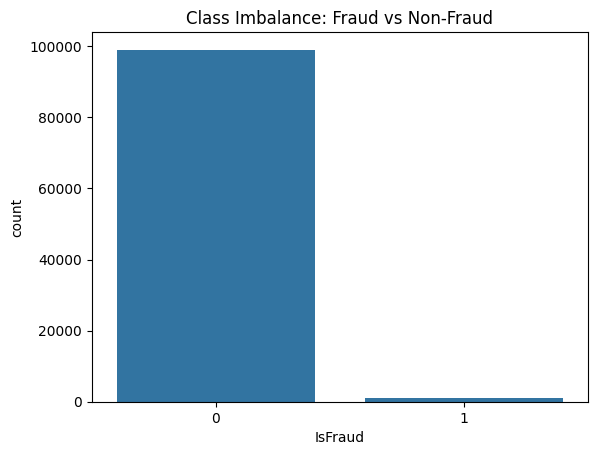

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="IsFraud", data=df)
plt.title("Class Imbalance: Fraud vs Non-Fraud")
plt.show()


In [5]:
# DROP ID 
df = df.drop(columns=["TransactionID"])


In [6]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["hour"] = df["TransactionDate"].dt.hour
df["day"] = df["TransactionDate"].dt.day
df["weekday"] = df["TransactionDate"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5,6]).astype(int)

df = df.drop(columns=["TransactionDate"])


In [7]:
# One-hot encoding
df = pd.get_dummies(
    df,
    columns=["TransactionType", "Location"],
    drop_first=True
)
df

,Amount,MerchantID,IsFraud,hour,day,weekday,is_weekend,TransactionType_refund,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,4189.27,688,0,14,3,2,0,True,False,False,False,False,False,False,True,False,False
1,2659.71,109,0,13,19,1,0,True,True,False,False,False,False,False,False,False,False
2,784.00,394,0,10,8,0,0,False,False,False,False,True,False,False,False,False,False
3,3514.40,944,0,23,13,5,1,False,False,False,False,False,True,False,False,False,False
4,369.07,475,0,18,12,4,0,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1057.29,289,0,0,7,4,0,True,False,False,False,False,False,False,True,False,False
99996,297.25,745,0,23,22,6,1,True,False,False,False,False,False,False,True,False,False
99997,3448.56,690,0,19,31,4,0,False,False,False,False,False,False,False,True,False,False
99998,3750.79,644,0,9,18,4,0,False,False,False,False,False,True,False,False,False,False


In [8]:
# TRAIN and TEST SPLIT

X = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [9]:
# SCALING 

num_cols = ["Amount", "MerchantID", "hour", "day", "weekday"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ],
    remainder="passthrough"
)

# PREPROCESS DATA

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)


# TRAIN ISOLATION FOREST

In [11]:
X_train_normal = X_train_p[y_train == 0]

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

iso.fit(X_train_normal)

iso_pred = iso.predict(X_test_p)
iso_pred = (iso_pred == -1).astype(int)

print("Isolation Forest Report")
print(classification_report(y_test, iso_pred))
print(confusion_matrix(y_test, iso_pred))
print("ROC-AUC:", roc_auc_score(y_test, iso_pred))


Isolation Forest Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.01      0.01      0.01       200

    accuracy                           0.98     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.98      0.98      0.98     20000

[[19594   206]
 [  198     2]]
ROC-AUC: 0.4997979797979798


# TRAIN A BASELINE (Logistic Regression)

In [12]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_p, y_train)

log_prob = log_model.predict_proba(X_test_p)[:, 1]
log_pred = log_model.predict(X_test_p)

print("Logistic ROC-AUC:", roc_auc_score(y_test, log_prob))
print(classification_report(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))


Logistic ROC-AUC: 0.4620651515151515
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     19800
           1       0.01      0.43      0.02       200

    accuracy                           0.54     20000
   macro avg       0.50      0.49      0.36     20000
weighted avg       0.98      0.54      0.69     20000

[[10693  9107]
 [  113    87]]


# RANDOM FOREST

In [13]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_p, y_train)

rf_prob = rf.predict_proba(X_test_p)[:, 1]
rf_pred = rf.predict(X_test_p)

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))


Random Forest ROC-AUC: 0.5026758838383838
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19800
           1       0.00      0.00      0.00       200

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.99     20000

[[19800     0]
 [  200     0]]


PR-AUC: 0.010989159123064144


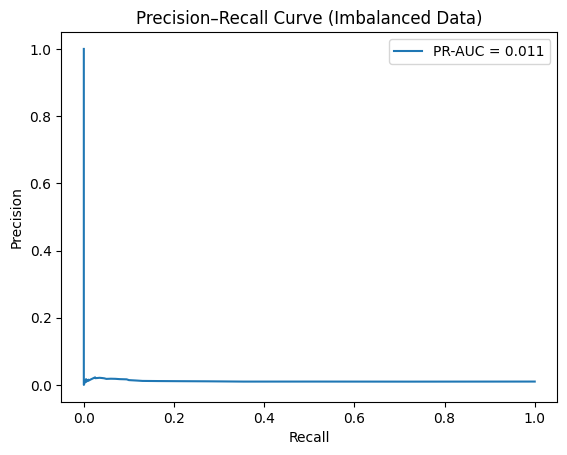

In [14]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, rf_prob)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Imbalanced Data)")
plt.legend()
plt.show()


In [16]:
# FRAUD CAPTURE @ K(BANK METRIC)

def fraud_capture_at_k(y_true, y_prob, k):
    df_eval = pd.DataFrame({
        "y": y_true,
        "prob": y_prob
    }).sort_values("prob", ascending=False)

    cutoff = int(len(df_eval) * k)
    return df_eval.head(cutoff)["y"].sum() / y_true.sum()

for k in [0.01, 0.03, 0.05, 0.10]:
    print(f"Fraud captured in top {int(k*100)}%:",
          fraud_capture_at_k(y_test, rf_prob, k))


Fraud captured in top 1%: 0.015
Fraud captured in top 3%: 0.05
Fraud captured in top 5%: 0.08
Fraud captured in top 10%: 0.125


# Threshold Optimization

In [17]:

threshold = np.percentile(rf_prob, 99)

print("Selected Risk Threshold:", threshold)

# Final binary decision ONLY for evaluation
final_preds = (rf_prob >= threshold).astype(int)

print("\nFinal Classification Report (Top 1% Risk):")
print(classification_report(y_test, final_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))


Selected Risk Threshold: 0.06666666666666667

Final Classification Report (Top 1% Risk):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19800
           1       0.02      0.03      0.02       200

    accuracy                           0.98     20000
   macro avg       0.51      0.51      0.51     20000
weighted avg       0.98      0.98      0.98     20000

Confusion Matrix:
[[19583   217]
 [  195     5]]


-------------------------------------
# SAVE TRAINED MODEL & PREPROCESSOR
-------------------------------------


In [19]:

import os
import joblib
import numpy as np

# Create artifacts folder
os.makedirs("artifacts", exist_ok=True)

# Save final model (Risk Scorer)
joblib.dump(rf, "artifacts/fraud_rf_model.pkl")

# Save preprocessor
joblib.dump(preprocessor, "artifacts/preprocessor.pkl")

# Save training reference risk scores (for percentile-based risk)
train_risk_scores = rf.predict_proba(X_train_p)[:, 1]
np.save("artifacts/reference_scores.npy", train_risk_scores)

# Save feature order (CRITICAL for Streamlit)
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "artifacts/feature_columns.pkl")

print("✅ All artifacts saved successfully!")


✅ All artifacts saved successfully!
